# Pedestrian Detection Project
This notebook implements a pedestrian detection model using **Faster R-CNN** with a MobileNet backbone.

### Workflow:
1. **Configuration**: Centralized settings for the project.
2. **Data Management**: Downloading and preparing the Penn-Fudan dataset.
3. **Model Setup**: Initializing the pre-trained model with a custom head.
4. **Training**: Running the training loop.
5. **CPU Benchmark**: Analysis of accuracy vs latency tradeoff on CPU
6. **Model Quantization**: Compressing the model.
7. **Inference**: Visualizing the results on test images.

## Imports

In [ ]:
!pip install torchmetrics

In [168]:
import os
import time
import zipfile
import random
import warnings
import urllib.request

import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## 1. Configuration
Adjust these values to change the training behavior or data paths.

In [175]:
class Config:
    # Dataset URL and paths
    DATA_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    DATA_DIR = "PennFudanPed"
    ZIP_FILENAME = "PennFudanPed.zip"

    # Model Hyperparameters
    BATCH_SIZE = 2
    NUM_EPOCHS = 15
    LEARNING_RATE = 0.005
    MOMENTUM = 0.9
    WEIGHT_DECAY = 0.0005
    STEP_SIZE = 3
    GAMMA = 0.1

    # Device Selection
    DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    NUM_WORKERS = 2 if torch.cuda.is_available() else 0

    # Benchmark Config
    NUM_SAMPLES = 20

cfg = Config()
print(f"[INFO] Current device: {cfg.DEVICE}")
if cfg.DEVICE.type == 'cpu':
    print("[WARNING] GPU not detected.")

[INFO] Current device: cuda


## 2. Data Preparation
Downloads the dataset and defines a custom `Dataset` class to handle images and masks.

In [176]:
def setup_dataset(cfg):
    if not os.path.exists(cfg.ZIP_FILENAME):
        print("Downloading dataset...")
        urllib.request.urlretrieve(cfg.DATA_URL, cfg.ZIP_FILENAME)

    if not os.path.exists(cfg.DATA_DIR):
        print("Extracting files...")
        with zipfile.ZipFile(cfg.ZIP_FILENAME, 'r') as zip_ref:
            zip_ref.extractall(".")

class PennFudanDataset(Dataset):
    def __init__(self, root_dir):
        self.root = root_dir
        self.imgs = sorted(os.listdir(os.path.join(root_dir, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root_dir, "PedMasks")))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        # Load and convert to float 0-1 range for the model
        img = read_image(img_path).float() / 255.0
        mask = read_image(mask_path)

        obj_ids = torch.unique(mask)[1:] # Exclude background
        masks = (mask == obj_ids[:, None, None])
        boxes = masks_to_boxes(masks)

        target = {
            "boxes": boxes,
            "labels": torch.ones((len(obj_ids),), dtype=torch.int64),
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(obj_ids),), dtype=torch.int64)
        }
        return img, target

    def __len__(self):
        return len(self.imgs)

setup_dataset(cfg)

## 3. Model Definition
Uses a pre-trained Faster R-CNN and modify the final layer to detect only one class (pedestrians).

In [177]:
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights="DEFAULT")
    # model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def collate_fn(batch):
    return tuple(zip(*batch))

## 4. Training Loop
Initializes the loaders, optimizer, and starts the training process.

In [178]:
def validate_model(model, val_data_loader, device):
    model.eval()

    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    with torch.no_grad():
        for images, targets in val_data_loader:
            images = list(img.to(device) for img in images)

            predictions = model(images)

            predictions = [{k: v.cpu() for k, v in p.items()} for p in predictions]
            targets = [{k: v.cpu() for k, v in t.items()} for t in targets]

            metric.update(predictions, targets)

    result = metric.compute()
    return result['map'].item(), result['map_50'].item()

Initializes the loaders and optimizer

In [190]:
dataset = PennFudanDataset(cfg.DATA_DIR)
indices = torch.randperm(len(dataset)).tolist()

train_loader = DataLoader(
    torch.utils.data.Subset(dataset, indices[:-50]),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False,
    collate_fn=collate_fn
)

test_subset = torch.utils.data.Subset(dataset, indices[-50:])
val_data_loader = DataLoader(
    test_subset,
    batch_size=1,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    collate_fn=collate_fn
)

model = get_model(num_classes=2).to(cfg.DEVICE)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, lr=cfg.LEARNING_RATE, momentum=cfg.MOMENTUM,
    weight_decay=cfg.WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=cfg.STEP_SIZE, gamma=cfg.GAMMA)



Starts the training process

In [191]:
print("Starting training loop...\n")
print(f" Epoch | {'Loss':<10} | {'mAP':<10} | {'mAP@50':<10} | {'Time':<8}")
print("-" * 55)

best_map = 0.0

for epoch in range(cfg.NUM_EPOCHS):
    model.train()
    start_time = time.time()
    epoch_loss = 0
    is_saved = False

    # Training
    for images, targets in train_loader:
        images = [img.to(cfg.DEVICE) for img in images]
        targets = [{k: v.to(cfg.DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    lr_scheduler.step()
    duration = time.time() - start_time

    # Check if this model outperforms the current best
    map, map_50 = validate_model(model, val_data_loader, cfg.DEVICE)

    if map > best_map:
        best_map = map
        torch.save(model.state_dict(), 'best_pedestrian_model.pth')
        is_saved = True

    epochs_counter = f" {epoch+1}/{cfg.NUM_EPOCHS}"
    print(f"{epochs_counter:>6} | {epoch_loss/len(train_loader):<10.4f} |" +
          f" {map:<10.4f} | {map_50:<10.4f}" +
          f" | {duration:<8.2f} | {'✓' if is_saved else 'x'}")

# Load best model
model.load_state_dict(torch.load('best_pedestrian_model.pth'))
model.eval();

Starting training loop...

 Epoch | Loss       | mAP        | mAP@50     | Time    
-------------------------------------------------------
  1/15 | 0.7816     | 0.6199     | 0.9474     | 4.15     | ✓
  2/15 | 0.7921     | 0.5869     | 0.9310     | 4.56     | x
  3/15 | 0.7889     | 0.6455     | 0.9450     | 4.03     | ✓
  4/15 | 0.5406     | 0.6920     | 0.9447     | 4.70     | ✓
  5/15 | 0.4392     | 0.7002     | 0.9361     | 4.03     | ✓
  6/15 | 0.3863     | 0.7031     | 0.9369     | 4.68     | ✓
  7/15 | 0.3372     | 0.7021     | 0.9278     | 4.02     | x
  8/15 | 0.3414     | 0.7073     | 0.9273     | 4.72     | ✓
  9/15 | 0.3315     | 0.7022     | 0.9273     | 4.43     | x
 10/15 | 0.3268     | 0.7030     | 0.9273     | 4.95     | x
 11/15 | 0.3247     | 0.7039     | 0.9273     | 3.97     | x
 12/15 | 0.3219     | 0.7053     | 0.9273     | 4.79     | x
 13/15 | 0.3272     | 0.7054     | 0.9273     | 4.01     | x
 14/15 | 0.3263     | 0.7054     | 0.9273     | 4.70     | x
 15/15

## 5. CPU Benchmark: Accuracy vs Latency
Measures inference time and confidence levels on CPU

In [201]:
def run_benchmark(model, dataset, device, num_samples, show_res=False):
    model.eval()
    model.to(device)

    latencies = []
    all_scores = []

    with torch.no_grad():
        # warm up
        _ = model([dataset[0][0].to(device)])

        for i in range(num_samples):
            img, _ = dataset[i]

            start = time.time()
            prediction = model([img.to(device)])
            end = time.time()

            latencies.append(end - start)
            scores = prediction[0]['scores']
            valid_scores = scores[scores > 0.5]
            all_scores.extend(valid_scores.tolist())

    map, map_50 = validate_model(model, val_data_loader, device)

    avg_latency = sum(latencies) / len(latencies) * 1000
    avg_conf = sum(all_scores) / len(all_scores) if all_scores else 0
    max_conf = max(all_scores) if all_scores else 0

    if show_res:
      print(f"--- Results ---")
      print(f"Average Latency: {avg_latency:.2f}ms per image ({1000 / avg_latency:.1f} FPS)")
      print(f"Average Confidence Score: {avg_conf:.4f}")
      print(f"Max Confidence: {max_conf:.4f}")
      return

    return avg_latency, 1000 / avg_latency, map, map_50

run_benchmark(model, test_subset, 'cpu', cfg.NUM_SAMPLES, True)

--- Results ---
Average Latency: 115.18ms per image (8.7 FPS)
Average Confidence Score: 0.9595
Max Confidence: 0.9994


## 6. Model Quantization
Compress the model using **Dynamic Quantization** (converting weights to 8-bit integers) to improve CPU inference speed and reduce memory usage.

In [193]:
def get_model_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    return size

def compare(label, orig, quant, unit="", _=4):
    diff = ((quant - orig) / orig) * 100
    print(f"{label:<10} | {orig:>7.{_}f}  ->  {quant:<7.{_}f} {unit:<3} | {diff:>+.2f}%")

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Model quantizition
model.to('cpu')
quant_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

# Size comparing
orig_size = get_model_size(model)
quant_size = get_model_size(quant_model)

# Benchmarks comparing
orig_lat, orig_fps, orig_map, orig_map_50 = run_benchmark(model, test_subset, 'cpu', cfg.NUM_SAMPLES)
quant_lat, quant_fps, quant_map, quant_map_50 = run_benchmark(quant_model, test_subset, 'cpu', cfg.NUM_SAMPLES)

#Accuracy check
with torch.no_grad():
    img, _ = dataset[0]
    orig_score = model([img])[0]['scores'][0].item()
    quant_score = quant_model([img])[0]['scores'][0].item()


print("------------- Quantization Report --------------")
compare("Size", orig_size, quant_size, "MB", 2)
compare("Latency", orig_lat, quant_lat, "ms", 2)
compare("Throughput", orig_fps, quant_fps, "FPS", 2)
compare("Confidence", orig_score, quant_score)
compare("mAP", orig_map, quant_map)
compare("mAP@50", orig_map_50, quant_map_50)

------------- Quantization Report --------------
Size       |   76.00  ->  34.29   MB  | -54.88%
Latency    |  107.01  ->  92.57   ms  | -13.49%
Throughput |    9.34  ->  10.80   FPS | +15.60%
Confidence |  0.9993  ->  0.9993      | +0.00%
mAP        |  0.7073  ->  0.7049      | -0.34%
mAP@50     |  0.9273  ->  0.9367      | +1.01%


## 7. Visualization
Shows how the model performs on a random test image.

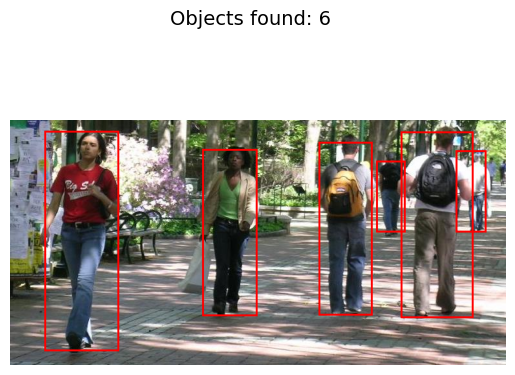

In [200]:
quant_model.eval()
quant_model.to('cpu')
img, _ = test_subset[random.randint(0, 49)]

with torch.no_grad():
    prediction = quant_model([img])

scores = prediction[0]['scores']
boxes = prediction[0]['boxes']
good_boxes = boxes[scores > 0.5]

img_int = (img * 255).to(torch.uint8)

if len(good_boxes) > 0:
    result_img = draw_bounding_boxes(img_int, good_boxes, colors="red", width=3)
    plt.imshow(result_img.permute(1, 2, 0).numpy())
    plt.suptitle(f"Objects found: {len(good_boxes)}", fontsize=14)
else:
    plt.imshow(img_int.permute(1, 2, 0).numpy())
    plt.suptitle("No objects found", fontsize=14)

plt.axis('off')
plt.show()

## Save models for further evaluation

In [202]:
scripted_model = torch.jit.script(model)
scripted_model.save("model.pt")

scripted_quant_model = torch.jit.script(quant_model)
scripted_quant_model.save("quant_model.pt")